In [29]:
import pandas as pd
from simple_linear_regression import SimpleLinearRegression

In this notebook, I'll be putting the SLR function to use on a kaggle dataset. I'll do a bit of pre-processing first using pandas, and then I'll do some visualizations in the end. I'll be explaining and coding along my thought process as I go through the entire notebook so you can get a sense of my decision-making along the way.

The dataset I'll be using is from Kaggle: https://www.kaggle.com/datasets/kumarajarshi/life-expectancy-who


Let's start by loading the csv file as a dataframe to get an idea of what we're working with

In [30]:
df = pd.read_csv('datasets/Life Expectancy Data.csv')
df

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2933,Zimbabwe,2004,Developing,44.3,723.0,27,4.36,0.000000,68.0,31,...,67.0,7.13,65.0,33.6,454.366654,12777511.0,9.4,9.4,0.407,9.2
2934,Zimbabwe,2003,Developing,44.5,715.0,26,4.06,0.000000,7.0,998,...,7.0,6.52,68.0,36.7,453.351155,12633897.0,9.8,9.9,0.418,9.5
2935,Zimbabwe,2002,Developing,44.8,73.0,25,4.43,0.000000,73.0,304,...,73.0,6.53,71.0,39.8,57.348340,125525.0,1.2,1.3,0.427,10.0
2936,Zimbabwe,2001,Developing,45.3,686.0,25,1.72,0.000000,76.0,529,...,76.0,6.16,75.0,42.1,548.587312,12366165.0,1.6,1.7,0.427,9.8


Right off the bat, I can foresee that the column titles would be a pain later on since there's no consistent naming convention so I'll take care of that right now. I'll start by replacing the spaces with underscores and changing all the letters into lowercase.

In [31]:
df.columns = [name.strip().replace(" ", "_").lower() for name in df.columns]
df.columns

Index(['country', 'year', 'status', 'life_expectancy', 'adult_mortality',
       'infant_deaths', 'alcohol', 'percentage_expenditure', 'hepatitis_b',
       'measles', 'bmi', 'under-five_deaths', 'polio', 'total_expenditure',
       'diphtheria', 'hiv/aids', 'gdp', 'population', 'thinness__1-19_years',
       'thinness_5-9_years', 'income_composition_of_resources', 'schooling'],
      dtype='object')

Some of these names are also really long, so I'll shorten them. There aren't really a lot of long-named columns in here so I can get away with hard-coding these changes.

In [32]:
df.rename(columns = {'thinness__1-19_years':'thin_1_19', 'thinness_5-9_years':'thin_5_9', 'income_composition_of_resources':'income' }, inplace = True)
df.columns

Index(['country', 'year', 'status', 'life_expectancy', 'adult_mortality',
       'infant_deaths', 'alcohol', 'percentage_expenditure', 'hepatitis_b',
       'measles', 'bmi', 'under-five_deaths', 'polio', 'total_expenditure',
       'diphtheria', 'hiv/aids', 'gdp', 'population', 'thin_1_19', 'thin_5_9',
       'income', 'schooling'],
      dtype='object')

That looks much more manageable than what we started with.

In [33]:
df

,country,year,status,life_expectancy,adult_mortality,infant_deaths,alcohol,percentage_expenditure,hepatitis_b,measles,...,polio,total_expenditure,diphtheria,hiv/aids,gdp,population,thin_1_19,thin_5_9,income,schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2933,Zimbabwe,2004,Developing,44.3,723.0,27,4.36,0.000000,68.0,31,...,67.0,7.13,65.0,33.6,454.366654,12777511.0,9.4,9.4,0.407,9.2
2934,Zimbabwe,2003,Developing,44.5,715.0,26,4.06,0.000000,7.0,998,...,7.0,6.52,68.0,36.7,453.351155,12633897.0,9.8,9.9,0.418,9.5
2935,Zimbabwe,2002,Developing,44.8,73.0,25,4.43,0.000000,73.0,304,...,73.0,6.53,71.0,39.8,57.348340,125525.0,1.2,1.3,0.427,10.0
2936,Zimbabwe,2001,Developing,45.3,686.0,25,1.72,0.000000,76.0,529,...,76.0,6.16,75.0,42.1,548.587312,12366165.0,1.6,1.7,0.427,9.8


Based on what I'm trying to do, the `country`, `year`, and `status` columns aren't really useful to me so I'll go ahead and just drop those. Dropping the columns won't really make a huge difference, but I guess I just want it to look a bit neater

In [34]:
df.drop(['country', 'year', 'status'], axis=1, inplace=True)
df

,life_expectancy,adult_mortality,infant_deaths,alcohol,percentage_expenditure,hepatitis_b,measles,bmi,under-five_deaths,polio,total_expenditure,diphtheria,hiv/aids,gdp,population,thin_1_19,thin_5_9,income,schooling
0,65.0,263.0,62,0.01,71.279624,65.0,1154,19.1,83,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,59.9,271.0,64,0.01,73.523582,62.0,492,18.6,86,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,59.9,268.0,66,0.01,73.219243,64.0,430,18.1,89,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,59.5,272.0,69,0.01,78.184215,67.0,2787,17.6,93,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,59.2,275.0,71,0.01,7.097109,68.0,3013,17.2,97,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2933,44.3,723.0,27,4.36,0.000000,68.0,31,27.1,42,67.0,7.13,65.0,33.6,454.366654,12777511.0,9.4,9.4,0.407,9.2
2934,44.5,715.0,26,4.06,0.000000,7.0,998,26.7,41,7.0,6.52,68.0,36.7,453.351155,12633897.0,9.8,9.9,0.418,9.5
2935,44.8,73.0,25,4.43,0.000000,73.0,304,26.3,40,73.0,6.53,71.0,39.8,57.348340,125525.0,1.2,1.3,0.427,10.0
2936,45.3,686.0,25,1.72,0.000000,76.0,529,25.9,39,76.0,6.16,75.0,42.1,548.587312,12366165.0,1.6,1.7,0.427,9.8


That looks good so far. We have `life_expectancy` as the leftmost column, and we have all our possible predictors immediately after. Let's see what we're working with here.

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   life_expectancy         2928 non-null   float64
 1   adult_mortality         2928 non-null   float64
 2   infant_deaths           2938 non-null   int64  
 3   alcohol                 2744 non-null   float64
 4   percentage_expenditure  2938 non-null   float64
 5   hepatitis_b             2385 non-null   float64
 6   measles                 2938 non-null   int64  
 7   bmi                     2904 non-null   float64
 8   under-five_deaths       2938 non-null   int64  
 9   polio                   2919 non-null   float64
 10  total_expenditure       2712 non-null   float64
 11  diphtheria              2919 non-null   float64
 12  hiv/aids                2938 non-null   float64
 13  gdp                     2490 non-null   float64
 14  population              2286 non-null   

We have 2938 rows with 19 columns, all formatted properly i.e. there are no cells with numeric values but are actually strings, for instance. Now let's look at how many null values we have per column.

In [36]:
df.isnull().sum()

life_expectancy            10
adult_mortality            10
infant_deaths               0
alcohol                   194
percentage_expenditure      0
hepatitis_b               553
measles                     0
bmi                        34
under-five_deaths           0
polio                      19
total_expenditure         226
diphtheria                 19
hiv/aids                    0
gdp                       448
population                652
thin_1_19                  34
thin_5_9                   34
income                    167
schooling                 163
dtype: int64

We seem to have a few columns with a lot of null values. Since my purpose for this notebook is to create a linear regression function from scratch and to use it on a dataset, I'm not too concerned about data integrity because I'm not particularly interested in the resulting model, so let's just drop the rows with null values to keep things simple.

In [37]:
df.dropna(how="any", axis=0, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1649 entries, 0 to 2937
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   life_expectancy         1649 non-null   float64
 1   adult_mortality         1649 non-null   float64
 2   infant_deaths           1649 non-null   int64  
 3   alcohol                 1649 non-null   float64
 4   percentage_expenditure  1649 non-null   float64
 5   hepatitis_b             1649 non-null   float64
 6   measles                 1649 non-null   int64  
 7   bmi                     1649 non-null   float64
 8   under-five_deaths       1649 non-null   int64  
 9   polio                   1649 non-null   float64
 10  total_expenditure       1649 non-null   float64
 11  diphtheria              1649 non-null   float64
 12  hiv/aids                1649 non-null   float64
 13  gdp                     1649 non-null   float64
 14  population              1649 non-null   float

Now let me export this into a new csv file just for documentation.

In [52]:
df.to_csv('Life Expectancy Cleaned.csv', index=False)

Next, I'll compute the correlation between `life_expectancy` with each of the possible predictors. There's probably a something I can use for that but since we're doing regression from scratch, why not do that from scratch as well. I'm going to write a `correlation()` function that will take in two pd.Series parameters, and will return the Pearson correlation coefficient $r$ between the two variables. I'll make use of the formula:

\begin{equation}
r = \frac{n \sum xy - (\sum x)(\sum y)}{\sqrt{[n \sum x^2 - (\sum x)^2][n \sum y^2 - (\sum y)^2]}}
\end{equation}

In [38]:
def corr(x: pd.Series, y: pd.Series):
  n = x.size
  numerator = (n*sum(x*y)) - (sum(x)*sum(y))
  denominator = (n*sum(x**2) - sum(x)**2)*(n*sum(y**2) - sum(y)**2)
  return numerator/denominator**(1/2)

We're trying to predict `life_expectancy` here using any of the other columns as predictors. Let's choose the top 3 predictors with the strongest correlation.

In [39]:
for column in df.columns[1:]:
  print(f"{column}: {corr(df[column], df['life_expectancy'])}")

adult_mortality: -0.7025230623069743
infant_deaths: -0.16907380399959623
alcohol: 0.40271832172735383
percentage_expenditure: 0.40963082412504764
hepatitis_b: 0.1999352763975771
measles: -0.06888122211117668
bmi: 0.5420415876915782
under-five_deaths: -0.1922653010530449
polio: 0.32729440310492963
total_expenditure: 0.1747176406423035
diphtheria: 0.3413312342606403
hiv/aids: -0.5922362925926371
gdp: 0.4413218099135654
population: -0.022304977802841134
thin_1_19: -0.4578381933498435
thin_5_9: -0.4575082867658006
income: 0.7210825929172857
schooling: 0.7276300323210981


That hurts my eyes; I'm not even gonna try to read all that. Let me use a Series instead.

In [40]:
corrs = pd.Series(index=df.columns[1:])
for column in df.columns[1:]:
  corrs[column] = corr(df[column], df['life_expectancy'])
corrs

adult_mortality          -0.702523
infant_deaths            -0.169074
alcohol                   0.402718
percentage_expenditure    0.409631
hepatitis_b               0.199935
measles                  -0.068881
bmi                       0.542042
under-five_deaths        -0.192265
polio                     0.327294
total_expenditure         0.174718
diphtheria                0.341331
hiv/aids                 -0.592236
gdp                       0.441322
population               -0.022305
thin_1_19                -0.457838
thin_5_9                 -0.457508
income                    0.721083
schooling                 0.727630
dtype: float64

That's much better to look at. Let's take the top 3 predictors with the highest magnitude of $r$. We have to take the absolute values because we're interested in the magnitudes of the correlation. If we used `.nlargest()` straight away, we would get the largest positive $r$ values, but not necessarily the largest $r$ magnitudes.

In [41]:
corrs = abs(corrs)
corrs.nlargest(3)

schooling          0.727630
income             0.721083
adult_mortality    0.702523
dtype: float64

Now, let's make the linear regression models for these predictors

In [42]:
model1 = SimpleLinearRegression(df['schooling'], df['life_expectancy'])
model2 = SimpleLinearRegression(df['income'], df['life_expectancy'])
model3 = SimpleLinearRegression(df['adult_mortality'], df['life_expectancy'])

With this, we can get the line equation. Let's use this on our three chosen predictors

In [43]:
print(model1.get_equation())
print(model2.get_equation())
print(model3.get_equation())

41.550341745363355 + 2.289786520456893x
47.421745795118916 + 34.64573756788659x
77.59823792779052 + -0.049317359295592646x


This part is usually skipped in practice, but to confirm our expectations from the theoretical part, let us verify that the determinant of the Hessian Matrix is indeed positive for all the predictors.

In [44]:
for predictor in ['schooling', 'income', 'adult_mortality']:
    x = df[predictor]
    n = x.size
    assert 4*n*sum(x**2) - 4*(sum(x)**2) > 0

To finish this up, let's go ahead and graph them

In [51]:
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
sns.set_theme()

Text(0.5, 0, 'Schooling')

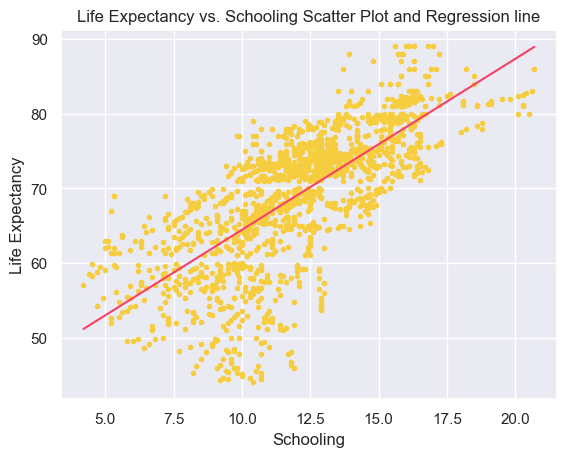

In [46]:
fig1, ax1 = plt.subplots()
x = np.linspace(min(df['schooling']), max(df['schooling']), 10)
ax1.scatter(df['schooling'], df['life_expectancy'], c='#f7cd40', marker='.')
ax1.plot(x, model1.get_intercept() + (model1.get_slope()*x), color='#f74065')
ax1.set_title('Life Expectancy vs. Schooling Scatter Plot and Regression line')
ax1.set_ylabel('Life Expectancy')
ax1.set_xlabel('Schooling')

Text(0.5, 0, 'Income')

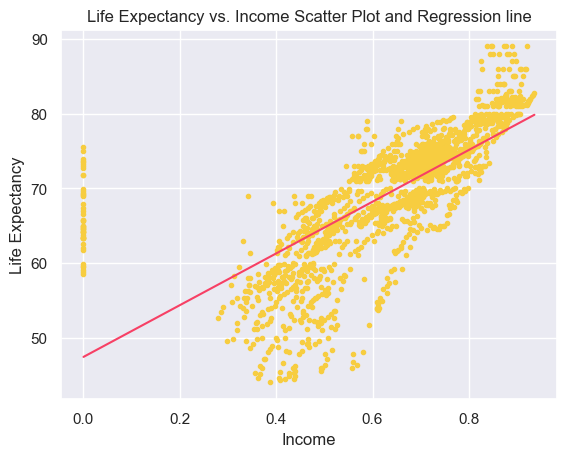

In [47]:
fig2, ax2 = plt.subplots()
x = np.linspace(min(df['income']), max(df['income']), 10)
ax2.scatter(df['income'], df['life_expectancy'], c='#f7cd40', marker='.')
ax2.plot(x, model2.get_intercept() + (model2.get_slope()*x), color='#f74065')
ax2.set_title('Life Expectancy vs. Income Scatter Plot and Regression line')
ax2.set_ylabel('Life Expectancy')
ax2.set_xlabel('Income')

Text(0.5, 0, 'Adult Mortality')

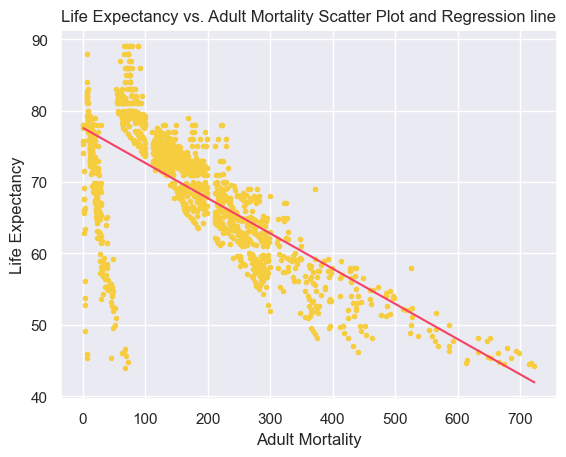

In [48]:
fig3, ax3 = plt.subplots()
x = np.linspace(min(df['adult_mortality']), max(df['adult_mortality']), 10)
ax3.scatter(df['adult_mortality'], df['life_expectancy'], c='#f7cd40', marker='.')
ax3.plot(x, model3.get_intercept() + (model3.get_slope()*x), color='#f74065')
ax3.set_title('Life Expectancy vs. Adult Mortality Scatter Plot and Regression line')
ax3.set_ylabel('Life Expectancy')
ax3.set_xlabel('Adult Mortality')

Now let me just save these as png.

In [49]:
fig1.savefig('Schooling.png')
fig2.savefig('Income.png')
fig3.savefig('Adult Mortality.png')

I guess that does it for this notebook. Bye :DD